# Chicklets

Developed by Cait Roufa

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import xarray as xr
import numpy as np
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
# Set style
sns.set(style='whitegrid')

# Load SCW event data per epoch
epochs = ['HIST', '4p5MID', '8p5MID', '4p5END', '8p5END']
epoch_labels = ['HIST', 'MID4.5', 'MID8.5', 'END4.5', 'END8.5']

df_HIST = pd.concat(map(pd.read_csv, glob.glob('/home/scratch/jcorner1/syn_sev/dataframes/HIST_UVV_[21]*_*')), ignore_index=True)
df_8p5END = pd.concat(map(pd.read_csv, glob.glob('/home/scratch/jcorner1/syn_sev/dataframes/EOC8p5_UVV*')), ignore_index=True)
df_4p5END = pd.concat(map(pd.read_csv, glob.glob('/home/scratch/jcorner1/syn_sev/dataframes/EOC4p5_UVV*')), ignore_index=True)
df_8p5MID = pd.concat(map(pd.read_csv, glob.glob('/home/scratch/jcorner1/syn_sev/dataframes/MC8p5_UVV*')), ignore_index=True)
df_4p5MID = pd.concat(map(pd.read_csv, glob.glob('/home/scratch/jcorner1/syn_sev/dataframes/MC4p5_UVV*')), ignore_index=True)

In [3]:
# Load and threshold WRF-BCC SCW events
def load_and_threshold(files):
    df = pd.concat(map(pd.read_csv, glob.glob(files)), ignore_index=True)
    df = df[(df['DBZ'] >= 40.0) & (df['UVV'] >= 25.0)].copy()
    df['Time'] = pd.to_datetime(df['Time'])
    df['Month'] = df['Time'].dt.month
    df['Year'] = df['Time'].dt.year
    df['New_Hour'] = (df['Time'] + pd.Timedelta(hours=12)).dt.hour  # shifted to center on 0Z
    return df

# File paths
df_map = {
    'HIST':    load_and_threshold('/home/scratch/jcorner1/syn_sev/dataframes/HIST_UVV_[21]*_*'),
    '4p5MID':  load_and_threshold('/home/scratch/jcorner1/syn_sev/dataframes/MC4p5_UVV*'),
    '8p5MID':  load_and_threshold('/home/scratch/jcorner1/syn_sev/dataframes/MC8p5_UVV*'),
    '4p5END':  load_and_threshold('/home/scratch/jcorner1/syn_sev/dataframes/EOC4p5_UVV*'),
    '8p5END':  load_and_threshold('/home/scratch/jcorner1/syn_sev/dataframes/EOC8p5_UVV*'),
}

In [4]:
# Load geo file
geog = xr.open_dataset('/home/scratch/WRF_BCC/geography/geo_em.d01.nc')

# Extract and flatten lat/lon arrays
lat_vals = geog['CLAT'].values.squeeze()
lon_vals = geog['CLONG'].values.squeeze()

ny, nx = lat_vals.shape
x_vals = np.tile(np.arange(nx), ny)
y_vals = np.repeat(np.arange(ny), nx)

lat_flat = lat_vals.flatten()
lon_flat = lon_vals.flatten()

# Make dataframe mapping (x, y) to (lat, lon)
coord_df = pd.DataFrame({'x': x_vals, 'y': y_vals, 'lat': lat_flat, 'lon': lon_flat})

/home/croufa/.local/lib/python3.9/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.31.0 or higher is recommended. You are running version 2.26.0
  warnings.warn(


In [5]:
# Ensure time column is parsed and month added
for epoch in df_map:
    df = df_map[epoch]
    df['Time'] = pd.to_datetime(df['Time'])
    df['Month'] = df['Time'].dt.month
    df['Year'] = df['Time'].dt.year
    df = df.merge(coord_df, on=['x', 'y'], how='left')
    df_map[epoch] = df

In [6]:
# Define regions
region_bounds = {
    'Northern Plains': {'lat_min': 40, 'lat_max': 49.5, 'lon_min': -110, 'lon_max': -95},
    'Southern Plains': {'lat_min': 25, 'lat_max': 40, 'lon_min': -110, 'lon_max': -95},
    'Southeast':       {'lat_min': 25, 'lat_max': 38, 'lon_min': -95, 'lon_max': -75},
    'Midwest':         {'lat_min': 38, 'lat_max': 49.5, 'lon_min': -95, 'lon_max': -80},
    'Northeast':       {'lat_min': 38, 'lat_max': 48, 'lon_min': -80, 'lon_max': -67}
}

In [7]:
# Define months
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

In [8]:
# Storage for each region’s monthly mean counts
region_monthly_means = {}

for region, bounds in region_bounds.items():
    regional_data = []

    for epoch in epochs:
        df = df_map[epoch]

        # Subset by region
        sub_df = df[
            (df['lat'] >= bounds['lat_min']) & (df['lat'] <= bounds['lat_max']) &
            (df['lon'] >= bounds['lon_min']) & (df['lon'] <= bounds['lon_max'])
        ].copy()

        # Count events per (Year, Month)
        grouped = sub_df.groupby(['Year', 'Month']).size().reset_index(name='Count')

        # Calculate monthly means
        monthly_means = grouped.groupby('Month')['Count'].mean()

        # Fill in any missing months with 0
        monthly_means = monthly_means.reindex(np.arange(1, 13), fill_value=0)

        # Store as row
        regional_data.append(monthly_means.values)

    # Create DataFrame with months 1–12 as columns
    # region_df = pd.DataFrame(regional_data, index=epoch_labels, columns=np.arange(1, 13))
    region_df = pd.DataFrame(regional_data, index=epoch_labels, columns=month_names)
    region_monthly_means[region] = region_df

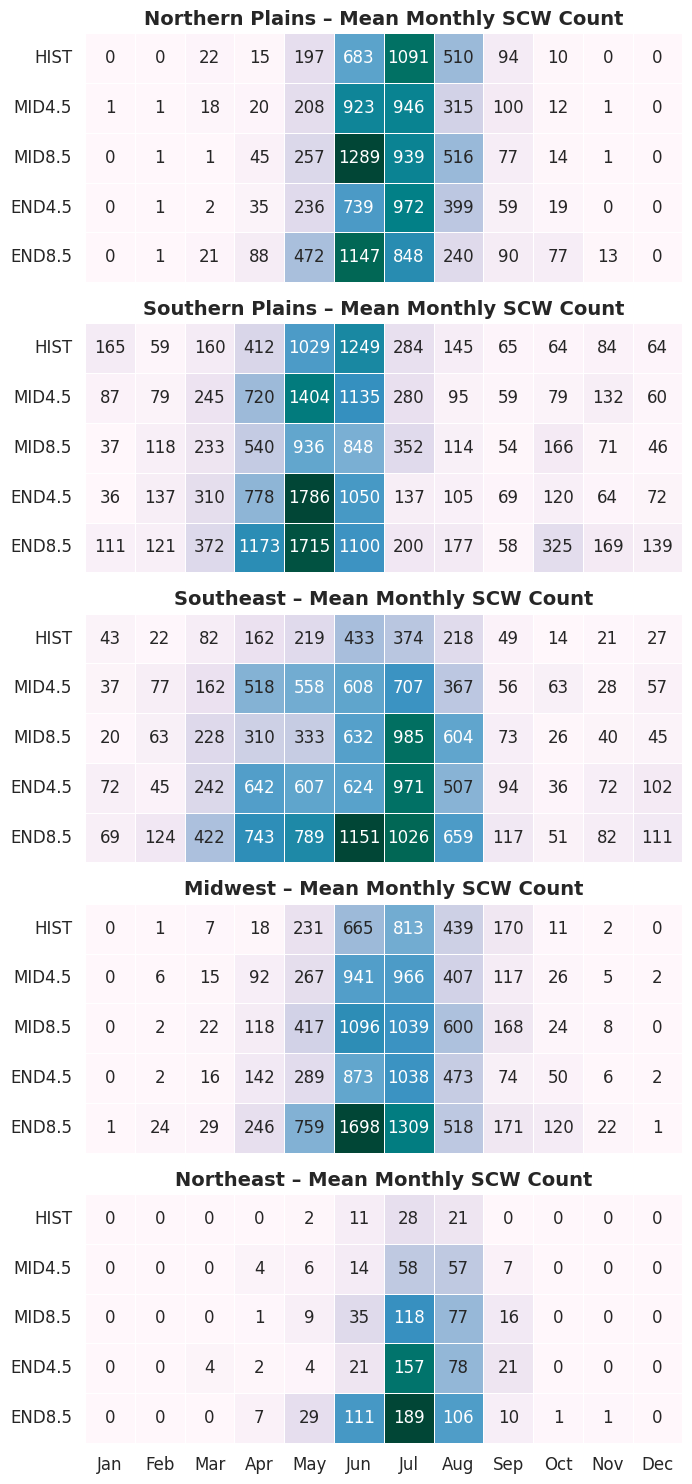

In [9]:
# plot chicklets mean monthly SCW count by region
fig, axs = plt.subplots(len(region_monthly_means), 1, figsize=(12, 3 * len(region_monthly_means)), sharex=True)

# # Get global min and max to apply consistent coloring
# all_vals = pd.concat(region_monthly_means.values()).values.flatten()
# vmin, vmax = np.min(all_vals), np.max(all_vals)

for i, (region, heat_df) in enumerate(region_monthly_means.items()):
    ax = axs[i]
    # sns.heatmap(heat_df, ax=ax, cmap='PuBu', cbar=i==0, linewidths=0.5, linecolor='white', annot=True, fmt=".0f")
    # sns.heatmap(heat_df, ax=ax, cmap='PuBuGn', cbar=False, vmin=vmin, vmax=vmax, linewidths=0.5, linecolor='white', annot=True, fmt=".0f")
    sns.heatmap(heat_df, ax=ax, cmap='PuBuGn', cbar=False, linewidths=0.5, linecolor='white', annot=True, fmt=".0f", square=True)
    ax.set_title(f'{region} – Mean Monthly SCW Count', fontsize=14, weight='bold')
    # ax.set_ylabel('Epoch')
    # ax.set_xlabel('Month')
    # ax.set_xticks(np.arange(12) + 0.5)
    # ax.set_xticklabels(np.arange(1, 13), fontsize=10)
    ax.set_xticklabels(month_names, fontsize=12, rotation=0)
    ax.set_yticklabels(epoch_labels, fontsize=12, rotation=0)

plt.tight_layout()

plt.savefig(f'../Plots/chiclet_regional.png', format='png', dpi=500, bbox_inches='tight')
    
plt.show()

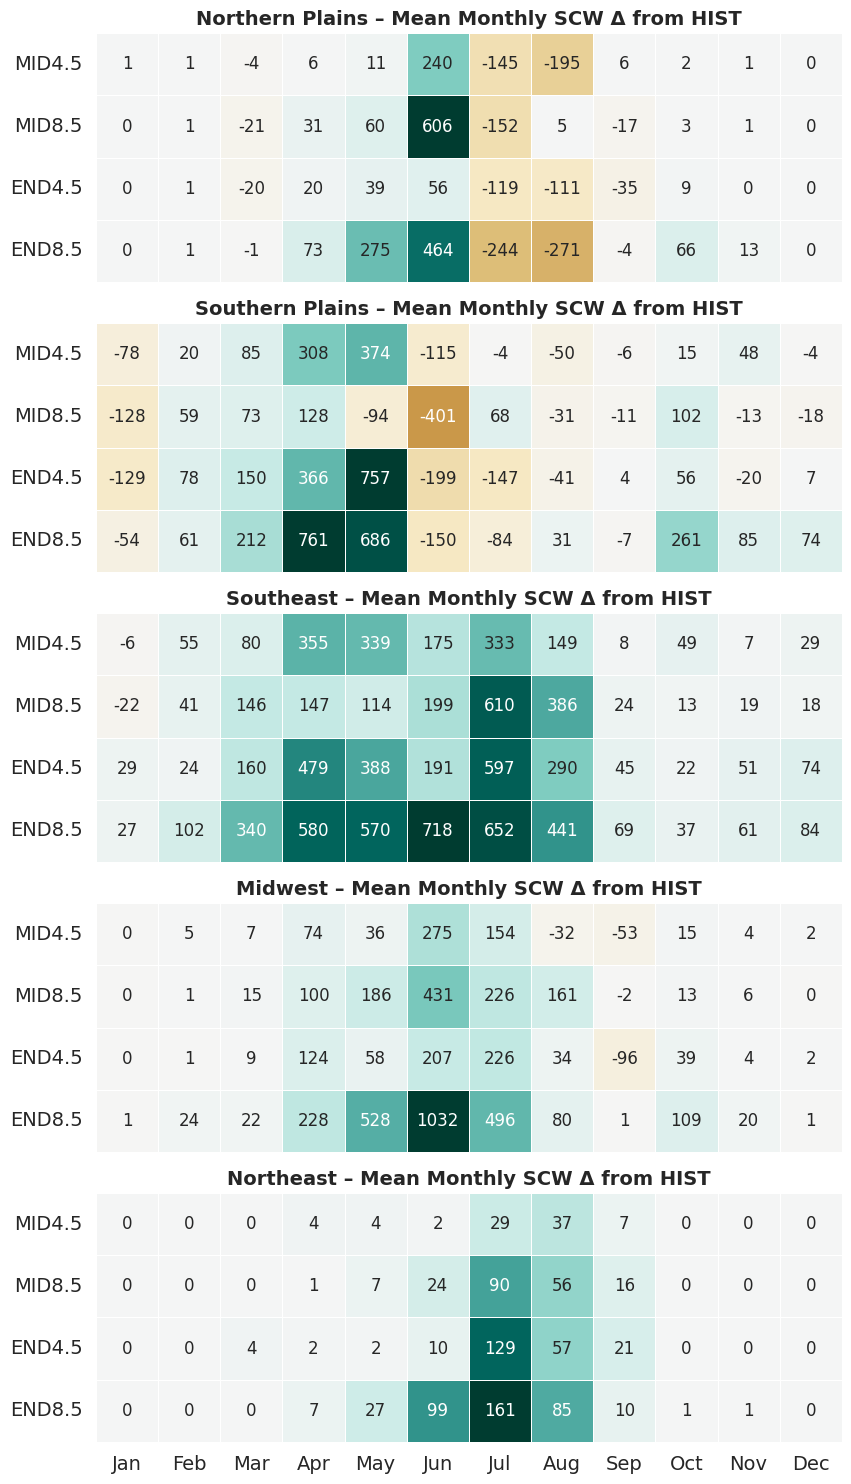

In [10]:
# plot chicklets mean monthly delta by region
fig, axs = plt.subplots(len(region_monthly_means), 1, figsize=(12, 3 * len(region_monthly_means)), sharex=True)

for i, (region, heat_df) in enumerate(region_monthly_means.items()):
    diff_df = heat_df.sub(heat_df.loc['HIST'], axis=1)
    
    # Drop HIST row from the difference DataFrame
    diff_df = diff_df.drop('HIST')

    ax = axs[i]
    # sns.heatmap(diff_df, ax=ax, cmap='BrBG', center=0, cbar=i==0,
    #             linewidths=0.5, linecolor='white', annot=True, fmt=".0f")
    sns.heatmap(diff_df, ax=ax, cmap='BrBG', center=0, cbar=False,
                linewidths=0.5, linecolor='white', annot=True, fmt=".0f", square=True)
    ax.set_title(f'{region} – Mean Monthly SCW Δ from HIST', fontsize=14, weight='bold')
    # ax.set_ylabel('Epoch')
    # ax.set_xlabel('Month')
    ax.set_xticks(np.arange(12) + 0.5)
    # ax.set_xticklabels(np.arange(1, 13), fontsize=10)
    ax.set_xticklabels(month_names, fontsize=14, rotation=0)
    # ax.set_yticklabels(epoch_labels, fontsize=10, rotation=0)
    ax.set_yticklabels(diff_df.index, fontsize=14, rotation=0)

plt.tight_layout()

plt.savefig(f'../Plots/chiclet_regional_delta.png', format='png', dpi=500, bbox_inches='tight')

plt.show()

In [11]:
# Compute full domain monthly means
domain_data = []

for epoch in epochs:
    df = df_map[epoch]
    
    # Group and compute mean monthly count across full domain
    grouped = df.groupby(['Year', 'Month']).size().reset_index(name='Count')
    monthly_means = grouped.groupby('Month')['Count'].mean()

    # Ensure all months are present
    monthly_means = monthly_means.reindex(np.arange(1, 13), fill_value=0)

    domain_data.append(monthly_means.values)

# Add to the region dictionary
region_monthly_means['ECONUS'] = pd.DataFrame(domain_data, index=epoch_labels, columns=month_names)

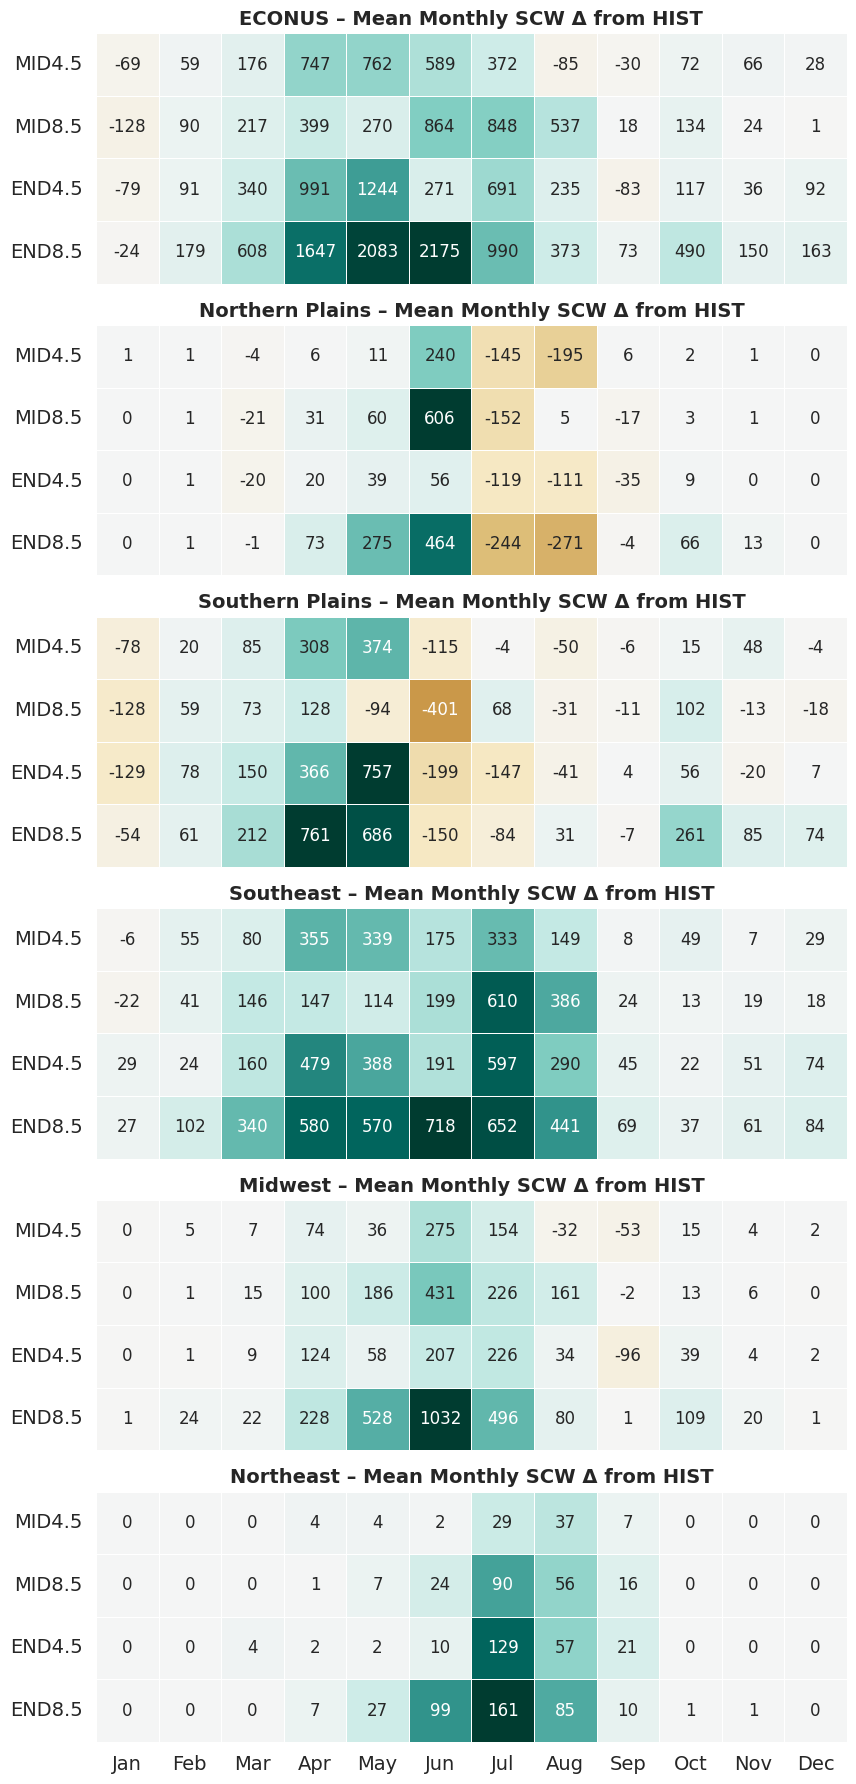

In [12]:
# plot mean monthly delta by region including entire domain
fig, axs = plt.subplots(len(region_monthly_means), 1, figsize=(12, 3 * len(region_monthly_means)), sharex=True)

for i, region in enumerate(['ECONUS'] + [r for r in region_monthly_means if r != 'ECONUS']):
    heat_df = region_monthly_means[region]

    diff_df = heat_df.sub(heat_df.loc['HIST'], axis=1)
    
    # Drop HIST row from the difference DataFrame
    diff_df = diff_df.drop('HIST')

    ax = axs[i]
    # sns.heatmap(diff_df, ax=ax, cmap='BrBG', center=0, cbar=i==0,
    #             linewidths=0.5, linecolor='white', annot=True, fmt=".0f")
    sns.heatmap(diff_df, ax=ax, cmap='BrBG', center=0, cbar=False,
                linewidths=0.5, linecolor='white', annot=True, fmt=".0f", square=True)
    ax.set_title(f'{region} – Mean Monthly SCW Δ from HIST', fontsize=14, weight='bold')
    # ax.set_ylabel('Epoch')
    # ax.set_xlabel('Month')
    ax.set_xticks(np.arange(12) + 0.5)
    # ax.set_xticklabels(np.arange(1, 13), fontsize=10)
    ax.set_xticklabels(month_names, fontsize=14, rotation=0)
    # ax.set_yticklabels(epoch_labels, fontsize=10, rotation=0)
    ax.set_yticklabels(diff_df.index, fontsize=14, rotation=0)

plt.tight_layout()

plt.savefig(f'../Plots/chiclet_regional_delta2.png', format='png', dpi=500, bbox_inches='tight')

plt.show()

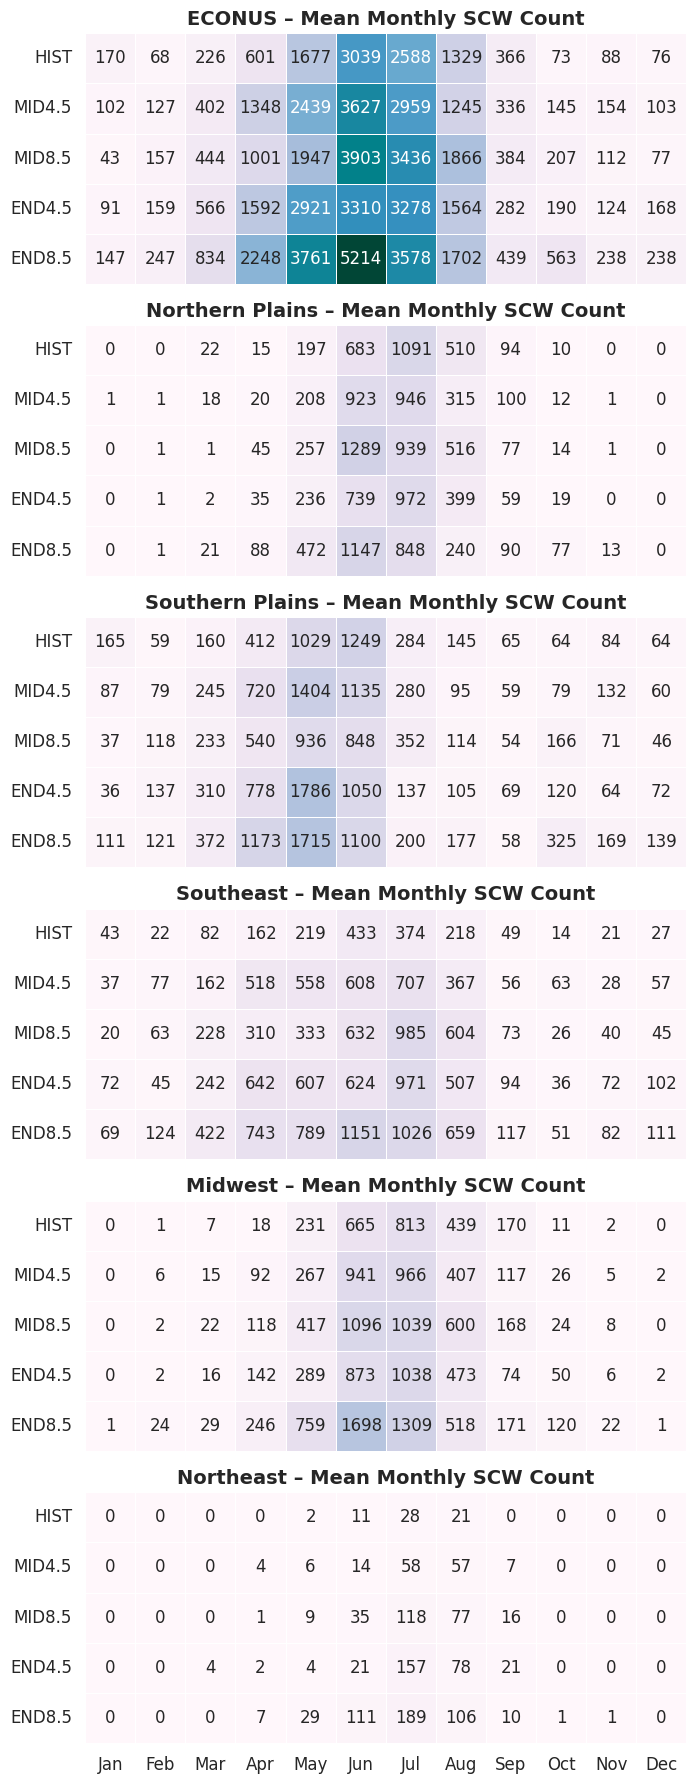

In [13]:
# Plot mean monthly count  by region including full domain
# Order regions with Full Domain first
ordered_regions = ['ECONUS'] + [r for r in region_monthly_means if r != 'ECONUS']

fig, axs = plt.subplots(len(ordered_regions), 1, figsize=(12, 3 * len(ordered_regions)), sharex=True)

# Get global min and max to apply consistent coloring
all_vals = pd.concat(region_monthly_means.values()).values.flatten()
vmin, vmax = np.min(all_vals), np.max(all_vals)

for i, region in enumerate(ordered_regions):
    heat_df = region_monthly_means[region]
    ax = axs[i]

    sns.heatmap(
        heat_df, ax=ax, cmap='PuBuGn', cbar=False,
        linewidths=0.5, linecolor='white', annot=True, fmt=".0f",
        square=True, vmin=vmin, vmax=vmax
    )

    ax.set_title(f'{region} – Mean Monthly SCW Count', fontsize=14, weight='bold')
    ax.set_xticklabels(month_names, fontsize=12, rotation=0)
    ax.set_yticklabels(epoch_labels, fontsize=12, rotation=0)

plt.tight_layout()
plt.savefig(f'../Plots/chiclet_regional2.png', format='png', dpi=500, bbox_inches='tight')
plt.show()

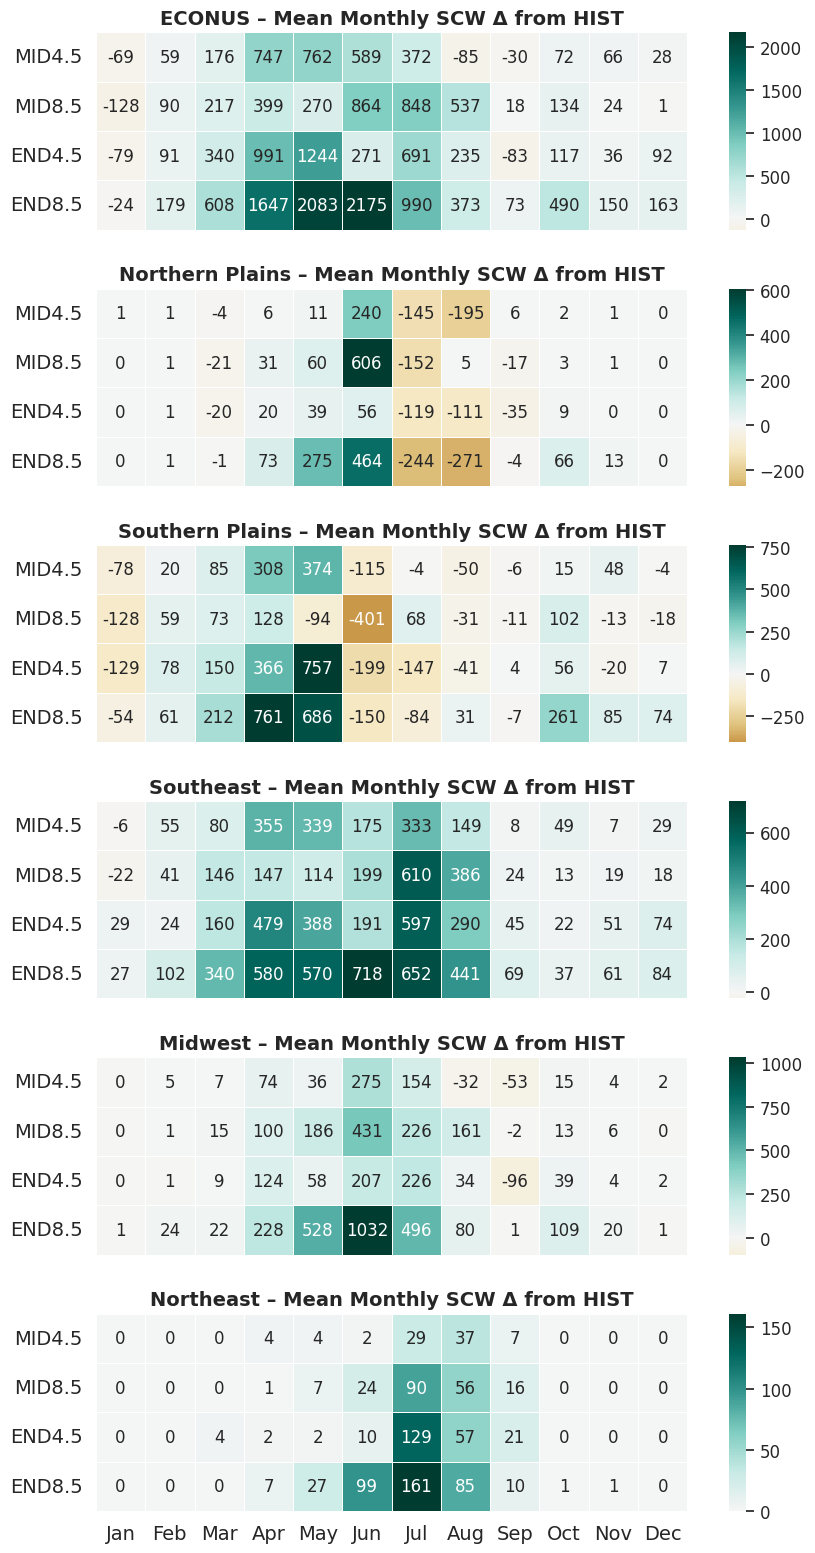

In [30]:
# Plot mean monthly delta including ECONUS
ordered_regions = ['ECONUS'] + [r for r in region_monthly_means if r != 'ECONUS']
n_regions = len(ordered_regions)

fig, axs = plt.subplots(n_regions, 1, figsize=(12, 3.2 * n_regions), sharex=True)

for i, region in enumerate(ordered_regions):
    heat_df = region_monthly_means[region]

    # Compute delta from HIST
    diff_df = heat_df.sub(heat_df.loc['HIST'], axis=1).drop('HIST')

    ax = axs[i]

    # Create vertical colorbar inset on the right side
    cax = inset_axes(ax,
                     width="3%",  # small width
                     height="100%",  # match the heatmap height
                     bbox_to_anchor=(0.1, 0, 1, 1),
                     bbox_transform=ax.transAxes,
                     borderpad=0)

    sns.heatmap(
        diff_df, ax=ax, cmap='BrBG', center=0,
        linewidths=0.5, linecolor='white', annot=True, fmt=".0f",
        square=True, cbar=True, cbar_ax=cax, cbar_kws={"orientation": "vertical"}
    )

    ax.set_title(f'{region} – Mean Monthly SCW Δ from HIST', fontsize=14, weight='bold')
    ax.set_xticklabels(month_names, fontsize=14, rotation=0)
    ax.set_yticklabels(diff_df.index, fontsize=14, rotation=0)
    cax.tick_params(labelsize=12)

plt.subplots_adjust(hspace=0.3, right=0.9)  # leave room for right-side colorbars
plt.savefig('../Plots/chiclet_regional_delta_cbar.png', format='png', dpi=500, bbox_inches='tight')
plt.show()

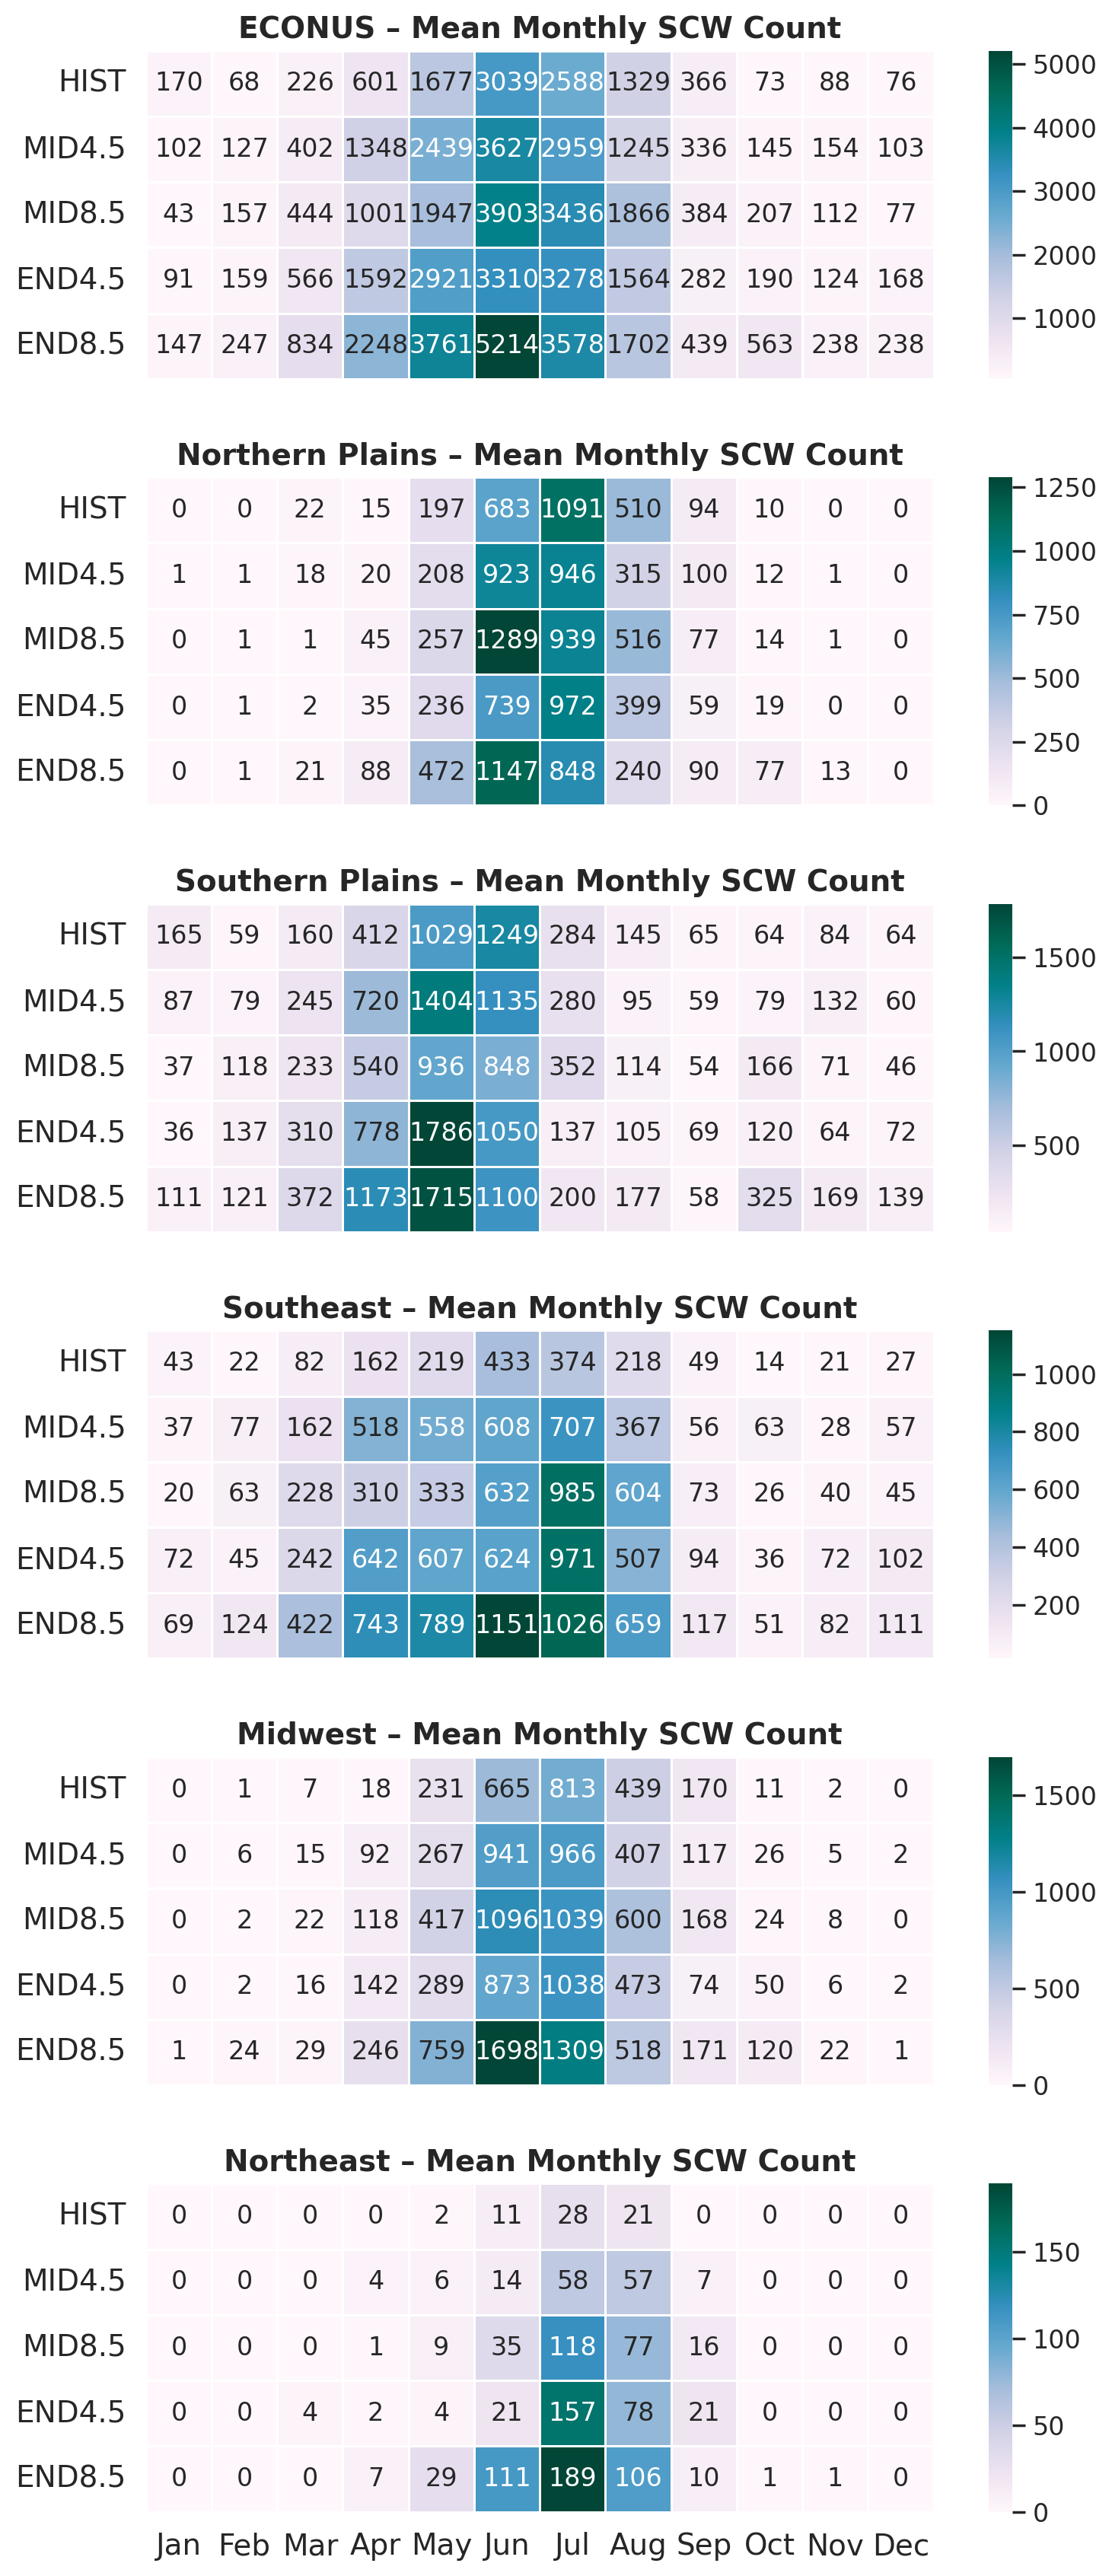

In [44]:
# Ensure consistent region order (with ECONUS first)
ordered_regions = ['ECONUS'] + [r for r in region_monthly_means if r != 'ECONUS']
n_regions = len(ordered_regions)

fig, axs = plt.subplots(n_regions, 1, figsize=(12, 3.5 * n_regions), sharex=True)

for i, region in enumerate(ordered_regions):
    heat_df = region_monthly_means[region]
    ax = axs[i]

    # Add vertical colorbar to the right of the heatmap
    cax = inset_axes(ax,
                     width="3%",           # width of colorbar
                     height="100%",        # full height of the axis
                     bbox_to_anchor=(0.1, 0, 1, 1),  # position to the right
                     bbox_transform=ax.transAxes,
                     borderpad=0)

    # Plot heatmap
    sns.heatmap(
        heat_df, ax=ax, cmap='PuBuGn', cbar=True,
        linewidths=0.5, linecolor='white', annot=True, fmt=".0f",
        square='true', cbar_ax=cax, cbar_kws={"orientation": "vertical"}
    )

    # Formatting
    ax.set_title(f'{region} – Mean Monthly SCW Count', fontsize=14, weight='bold')
    ax.set_xticklabels(month_names, fontsize=14, rotation=0)
    ax.set_yticklabels(epoch_labels, fontsize=14, rotation=0)
    cax.tick_params(labelsize=12)

plt.subplots_adjust(hspace=0.3, right=0.9)  # tighten vertical spacing and reserve room for colorbars
plt.savefig('../Plots/chiclet_regional_count_cbar.png', format='png', dpi=500, bbox_inches='tight')
plt.show()